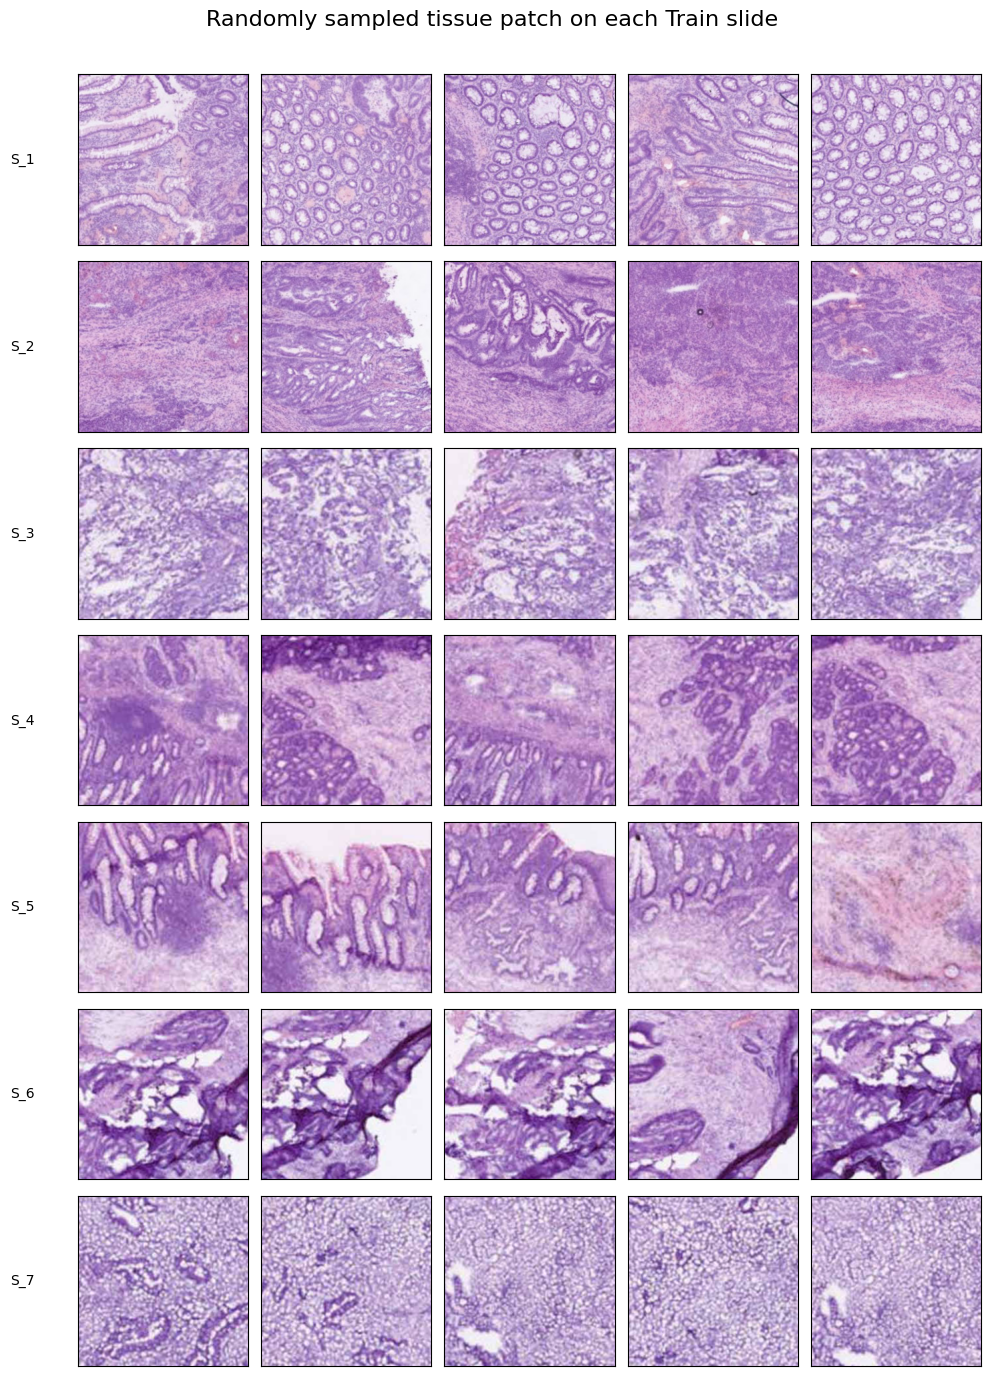

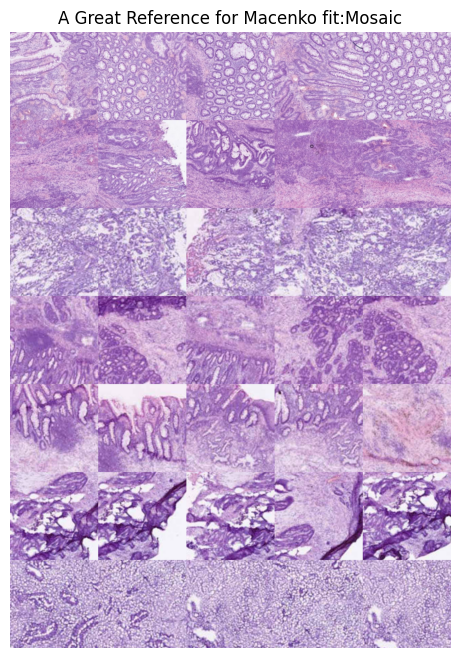

 Train/S_1 normalization and writing complete
 Train/S_2 normalization and writing complete
 Train/S_3 normalization and writing complete
 Train/S_4 normalization and writing complete
 Train/S_5 normalization and writing complete
 Train/S_6 normalization and writing complete
 Test/S_7 normalization and writing complete

The new normalized HDF5 has been saved to：C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\data_preprocessing\Image_preprocessing\try.h5


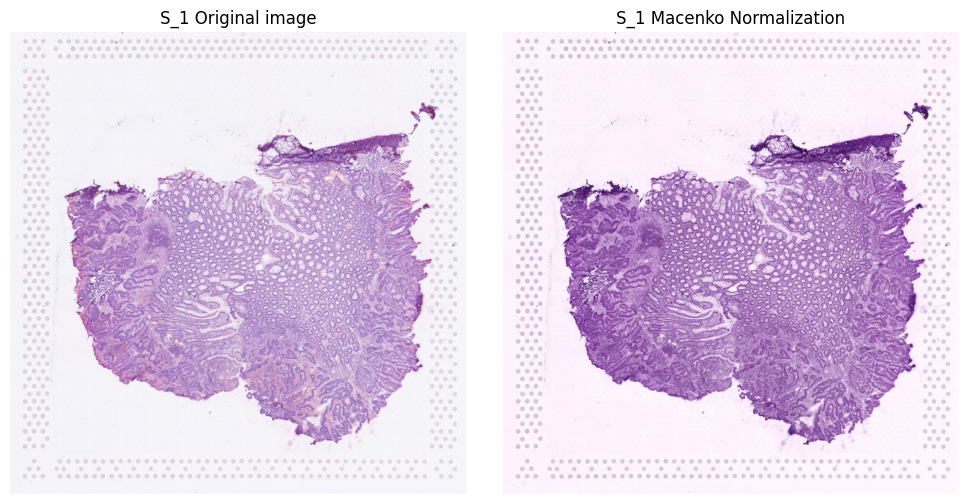

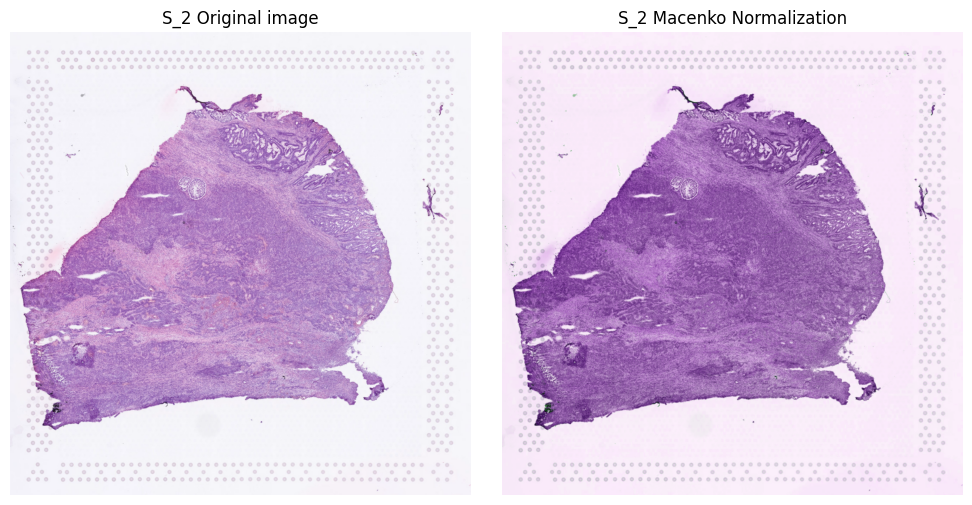

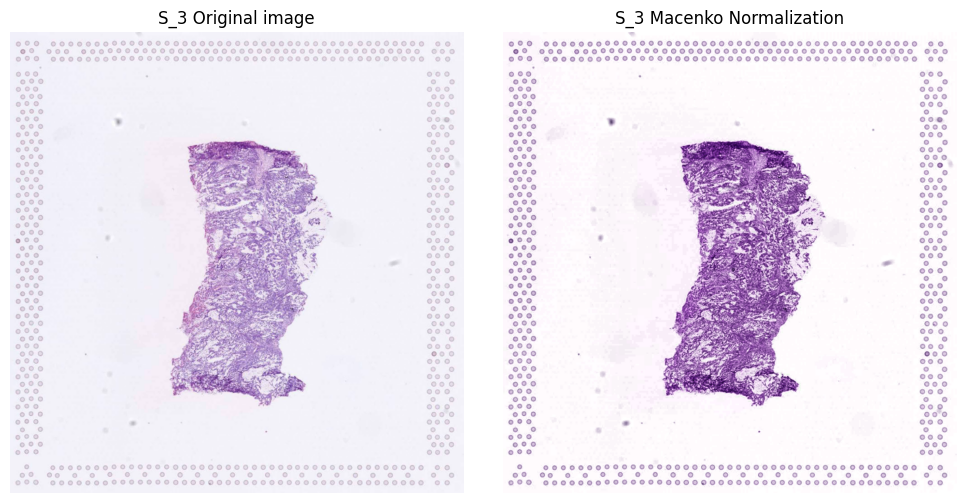

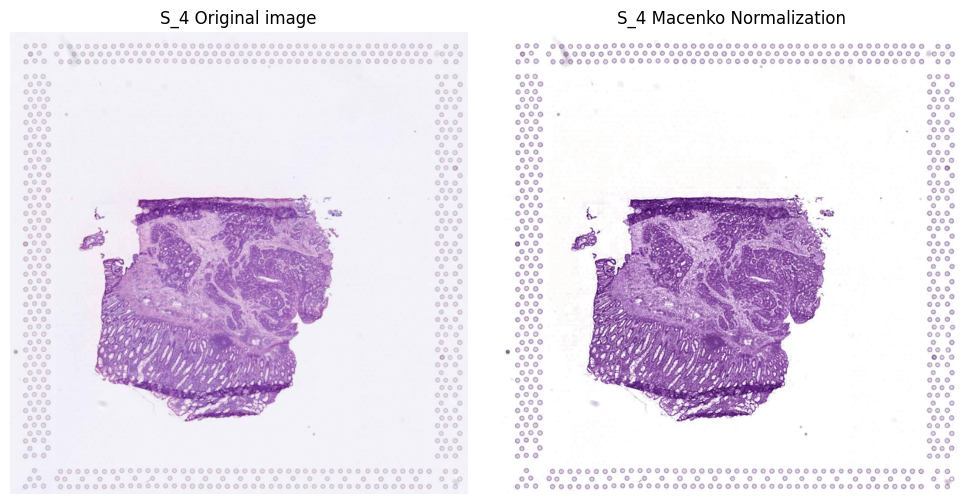

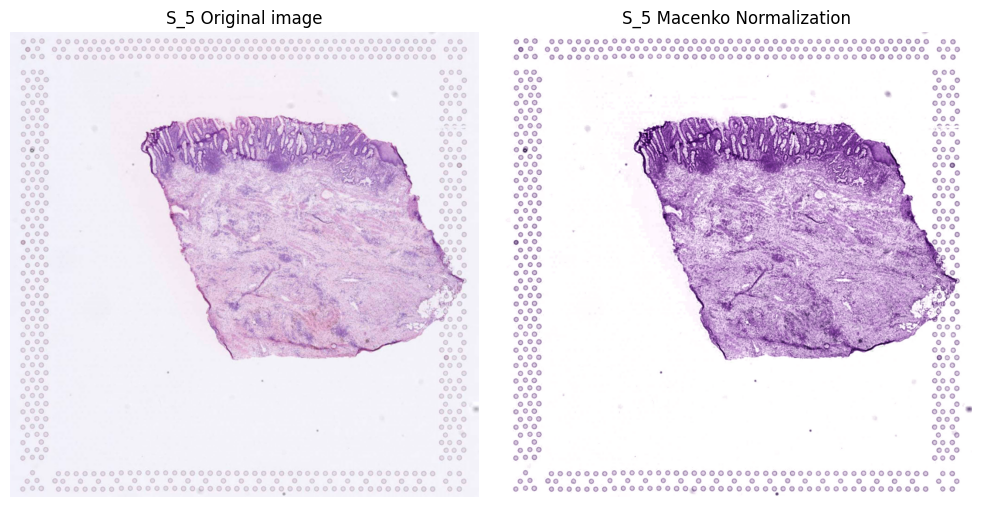

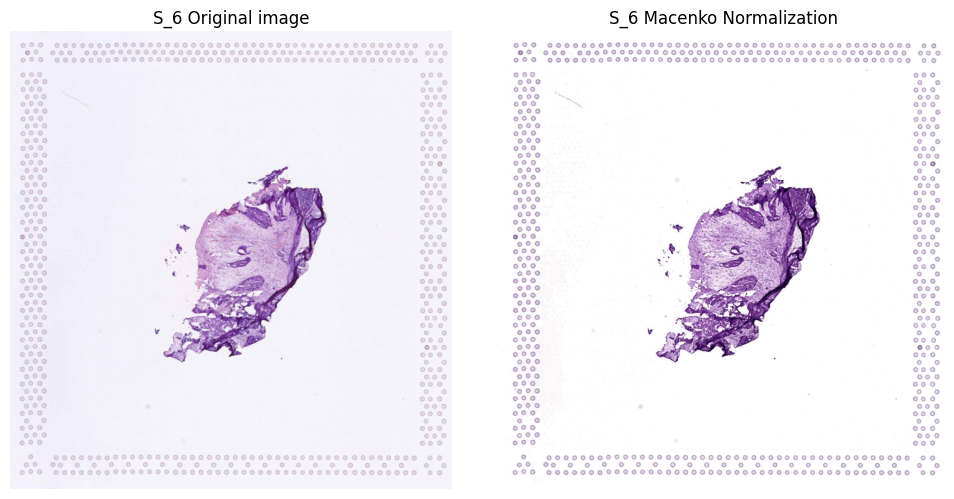

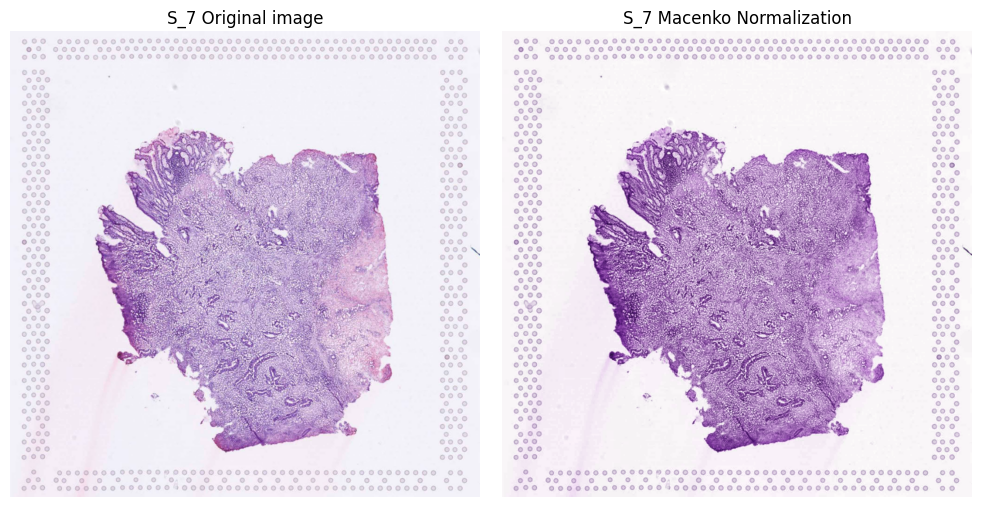

In [ ]:
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'scripts'))
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
import torchstain
from scripts.image_preprocessing import make_tissue_mask, sample_tissue_patches_np, normalize_np_image

# -----------------------------------------------------------------------------
# 1) Read all Train slides from HDF5 and sample patches
# -----------------------------------------------------------------------------
src_path = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5"
patch_size     = 256
n_patches      = 5
min_frac       = 0.6
seed           = 46
# wanted = {"S_7", "S_6","S_4", "S_5"}
wanted = {"S_1", "S_2", "S_3","S_4", "S_5" , "S_6", "S_7"}
all_patches = {}  # slide_id -> list of patches



with h5py.File(src_path, "r") as h5:
    for split in ["Train", "Test"]:
        train_grp = h5[f"images/{split}"]
        for sid in sorted(train_grp.keys()):
            if sid not in wanted:
                continue   
            img = np.array(train_grp[sid], dtype=np.float32)  # [0,1]
            mask = make_tissue_mask(img, thresh=0.8)
            patches = sample_tissue_patches_np(
                img, mask,
                patch_size=patch_size,
                n_patches=n_patches,
                min_frac=min_frac,
                seed=seed
            )
            all_patches[sid] = patches

# -----------------------------------------------------------------------------
# 2) Display sampled patches in a grid per slide
# -----------------------------------------------------------------------------
n_slides = len(all_patches)
fig, axes = plt.subplots(
    n_slides, n_patches,
    figsize=(n_patches*2, n_slides*2),
    squeeze=False
)

for i, (sid, patches) in enumerate(all_patches.items()):
    for j, patch in enumerate(patches):
        ax = axes[i][j]
        ax.imshow((patch*255).astype(np.uint8))
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(sid, rotation=0, labelpad=40, va="center")
plt.suptitle("Randomly sampled tissue patch on each Train slide ", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


# -----------------------------------------------------------------------------
# 3) Concatenate all patches horizontally into one large image
# -----------------------------------------------------------------------------

rows = []
for sid, patches in all_patches.items():
    row = np.hstack([(p*255).astype(np.uint8) for p in patches])
    rows.append(row)
big_ref = np.vstack(rows)  # uint8 [0,255]

# 3) Convert to Tensor，do not multiply by 255 again
to_tensor255 = transforms.Compose([
    transforms.ToTensor(),          # H×W×3 uint8→C×H×W float [0,1]
    transforms.Lambda(lambda t: t*255)  # →[0,255]
])
template_t = to_tensor255(big_ref)   # shape [3,H,W], values in [0,255]

normalizer = torchstain.normalizers.MacenkoNormalizer(backend="torch")
normalizer.fit(template_t)

# 2) Show the reference image
plt.figure(figsize=(8,8))
plt.imshow(big_ref)
plt.axis("off")
plt.title("A Great Reference for Macenko fit:Mosaic")
plt.show()


# -----------------------------------------------------------------------------
# 4) Normalize all slides and write to new HDF5 (same group structure)
# -----------------------------------------------------------------------------

dst_path = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Image_preprocessing\\try.h5"
os.makedirs(os.path.dirname(dst_path), exist_ok=True)

with h5py.File(src_path, "r") as src, \
     h5py.File(dst_path, "w") as dst:

    for split in ["Train", "Test"]:
        grp_in  = src[f"images/{split}"]
        grp_out = dst.create_group(f"images/{split}")

        for slide_id in grp_in.keys():
            # View original image [0,1]
            img = np.array(grp_in[slide_id], dtype=np.float32)
            # Using torchstain for normalization，we get uint8 [0,255]
            norm_u8 = normalize_np_image(img,to_tensor_fn= to_tensor255, normalizer = normalizer )
            # Convert back to float32 [0,1]
            norm_f = norm_u8.astype(np.float32) / 255.0
            # Drawing
            fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
            ax0.imshow((img * 255).astype(np.uint8))
            ax0.set_title(f"{slide_id} Original image")
            ax0.axis("off")
            ax1.imshow(norm_u8)
            ax1.set_title(f"{slide_id} Macenko Normalization")
            ax1.axis("off")
            plt.tight_layout()
            # Write a new file and enable gzip compression
            grp_out.create_dataset(
                name=slide_id,
                data=norm_f
            )
            print(f" {split}/{slide_id} normalization and writing complete")

print(f"\nThe new normalized HDF5 has been saved to：{dst_path}")